In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Loading data from CSV file

df = pd.read_csv("/content/water_potability.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


#### Observations:

1. The Potability column is having discrete numerical values.
2. All the remaining columns are real numerical

<Axes: >

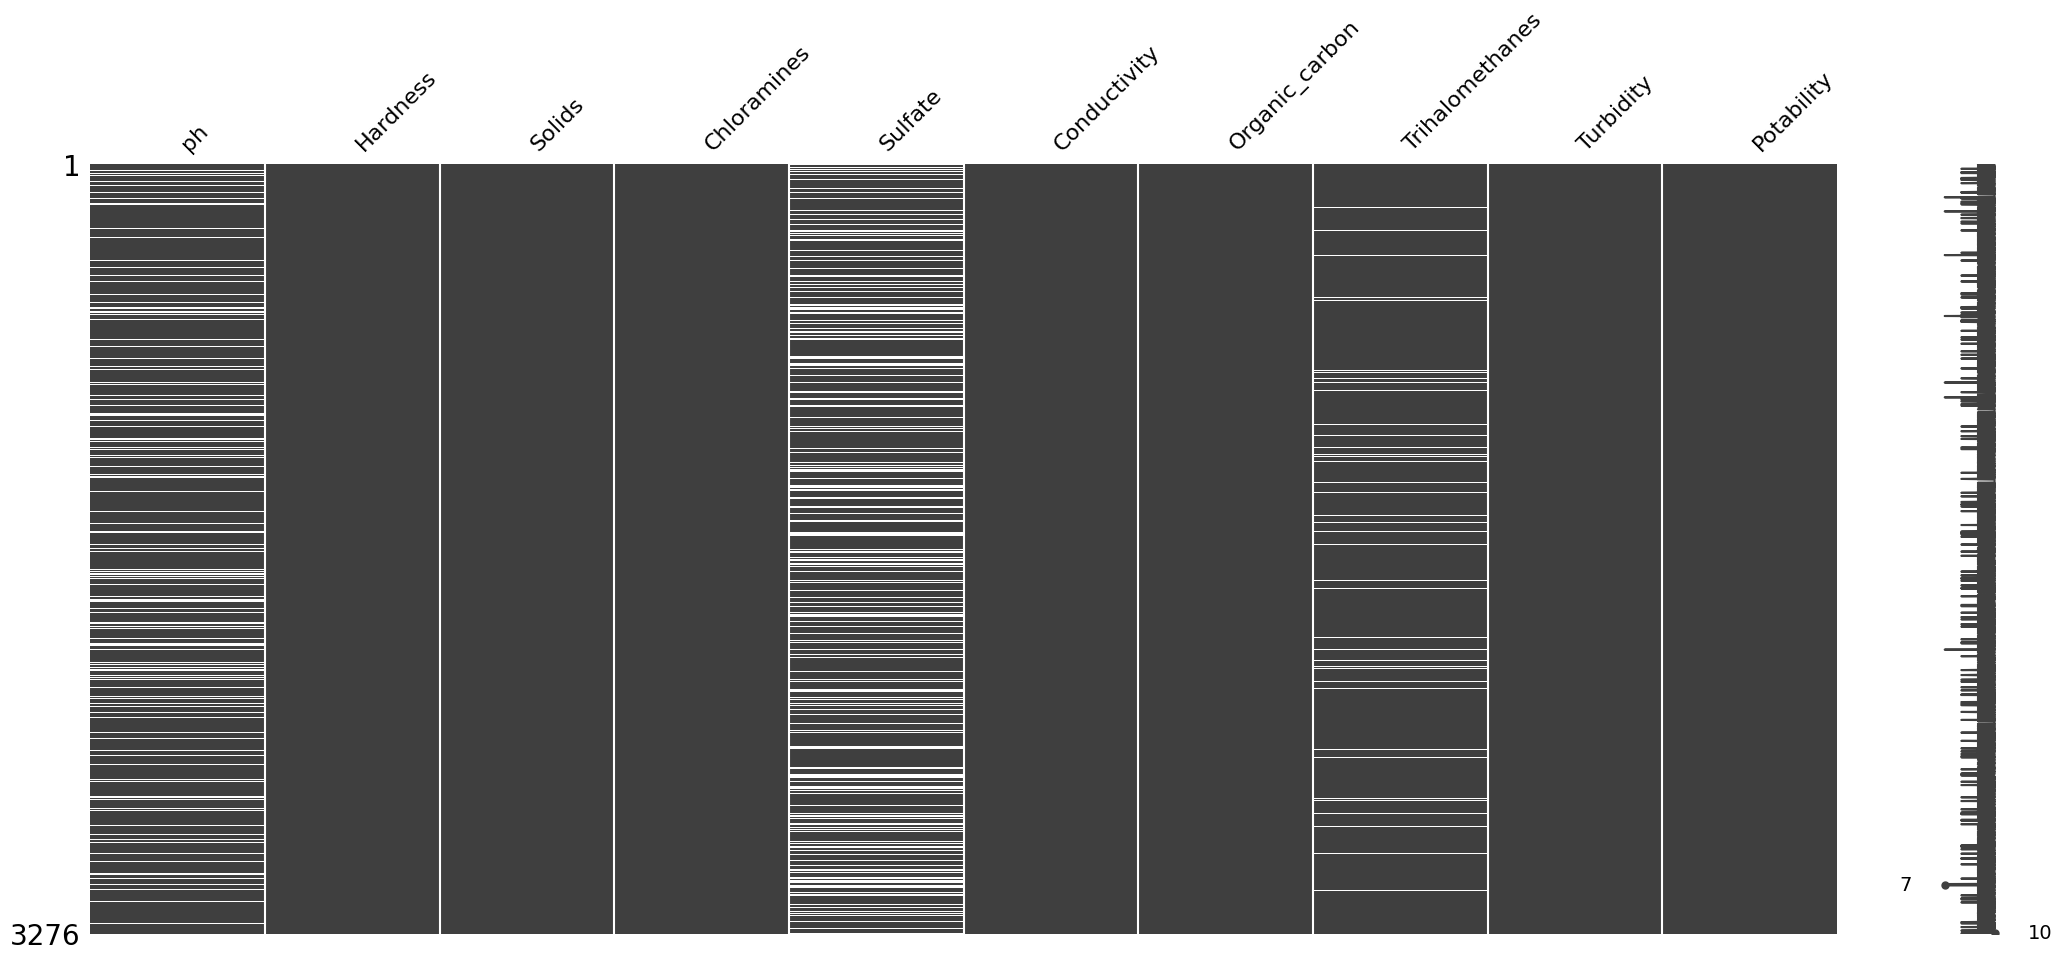

In [ ]:
import missingno as msn
msn.matrix(df)

In [ ]:
# percentage of missing values per column
df.isnull().sum()/len(df)*100

,0
ph,14.987790
Hardness,0.000000
Solids,0.000000
Chloramines,0.000000
Sulfate,23.840049
Conductivity,0.000000
Organic_carbon,0.000000
Trihalomethanes,4.945055
Turbidity,0.000000
Potability,0.000000


#### Observations:
1. Out of three columns, two columns are having low missing values.
2. One column (sulphate) has large number of missing values. Let us drop this column.

<Axes: xlabel='ph'>

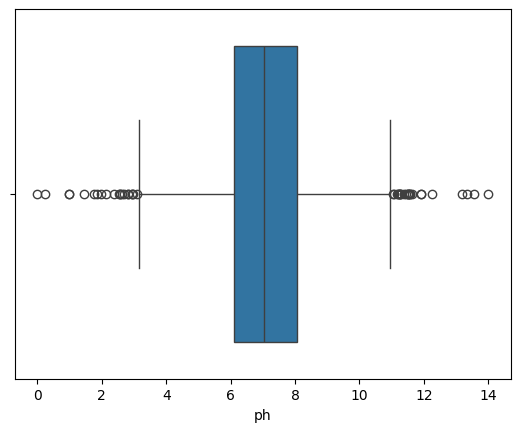

In [ ]:
# Visualize outliers in ph column.

sns.boxplot(df, x='ph')

<Axes: xlabel='Trihalomethanes'>

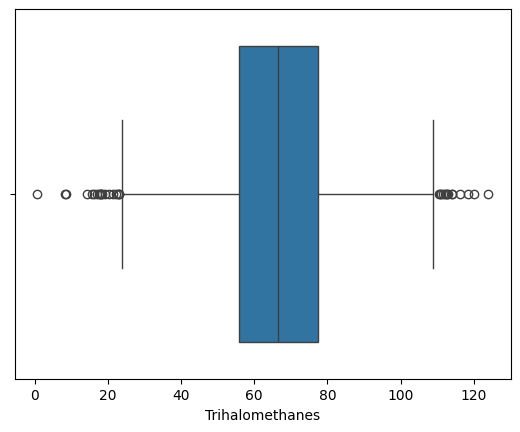

In [ ]:
sns.boxplot(df, x="Trihalomethanes")

**Observations:**

- Both the columns are having outlier. Hence, median based imputation is suggested.

<Axes: xlabel='ph', ylabel='Density'>

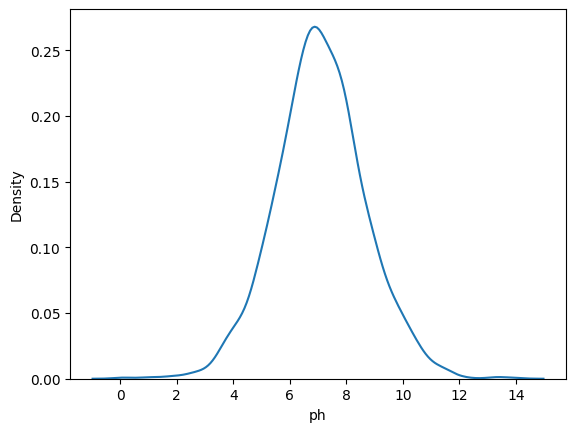

In [ ]:
sns.kdeplot(df,x="ph")

In [ ]:
# Filling Missing Values Using Simple Imputers
df["ph"]=df["ph"].fillna(df["ph"].median())
df["Trihalomethanes"]=df["Trihalomethanes"].fillna(
                                  df["Trihalomethanes"].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
# Let us drop sulphates columns
df=df.drop(columns="Sulfate")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Conductivity     3276 non-null   float64
 5   Organic_carbon   3276 non-null   float64
 6   Trihalomethanes  3276 non-null   float64
 7   Turbidity        3276 non-null   float64
 8   Potability       3276 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 230.5 KB


**Observations:**

1. Potability column is target variable.

2. It is a **Supervised Machine Learning** Model.

3. Potability is a discrete numerical data column. Hecne, It is a **Classification Model**.

4. We can use **Accurcay Score** as evaluaton metric to validate the model.


### **1. Selection of Target Variable and Predictors**

In [ ]:
# Let us select output variable (Target Variable) and Input Variables(predictors)
y=df["Potability"] # target variable
X=df.drop(columns=["Potability"]) # predictors

In [ ]:
X.shape

(3276, 8)

In [ ]:
y.shape

(3276,)

In [ ]:
# Let us verify sklearn availability in the computer.
import sklearn

# pip install sklearn

### **Step No 2: Splitting Data into Train data and Test data**

In [ ]:
# splitting data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2620, 8)
(656, 8)
(2620,)
(656,)


In [ ]:
X_train.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2417,7.159053,161.478710,25591.840984,10.189528,330.550453,15.447842,51.188317,4.291669
2920,8.091812,200.973301,26472.691803,6.725680,432.189931,13.798655,32.667078,4.370031
202,8.369154,183.500378,12975.900334,6.600853,493.465440,12.987106,87.029410,3.629749
863,7.685397,230.335708,7324.701425,7.991366,492.850391,14.233952,74.068658,4.179187
2488,6.862936,220.147889,23580.657290,6.611543,325.721747,13.472758,89.412935,3.806093


### **Min - Max Scaling**

In [ ]:
# min - max scalar
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_norm=scaler.fit_transform(X_train) # X_train_trans
X_test_norm=scaler.transform(X_test) # X_test_trans

In [ ]:
# Display top5 rows in X_train_norm and X_test_norm
# verify the data type of X_train_norm and X_test_norm

In [ ]:
type(X_train_norm)

numpy.ndarray

In [ ]:
type(X_test_norm)

numpy.ndarray

In [ ]:
X_train_norm.shape

(2620, 8)

In [ ]:
# Let us convert numpy array into a Data Frame
X_train_norm=pd.DataFrame(X_train_norm,columns=X_train.columns)
X_train_norm.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.511361,0.413674,0.446901,0.770061,0.260670,0.507580,0.409293,0.563348
1,0.577987,0.556931,0.462479,0.498918,0.438406,0.444393,0.259034,0.578883
2,0.597797,0.493552,0.223796,0.489147,0.545557,0.413299,0.700065,0.432126
3,0.548957,0.663435,0.123857,0.597993,0.544482,0.461071,0.594917,0.541049
4,0.490210,0.626481,0.411335,0.489984,0.252227,0.431906,0.719402,0.467085


In [ ]:
X_test_norm=pd.DataFrame(X_test_norm,columns=X_train.columns)
X_test_norm.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.535598,0.686572,0.378720,0.488185,0.205838,0.710255,0.548233,0.553550
1,0.588754,0.392409,0.419497,0.570427,0.414053,0.423979,0.534146,0.412237
2,0.498242,0.574947,0.395508,0.436459,0.455150,0.433642,0.626644,0.690184
3,0.333436,0.530482,0.835767,0.533436,0.603192,0.448062,0.535037,0.591926
4,0.704945,0.639629,0.516893,0.576511,0.305492,0.459872,0.675598,0.651603


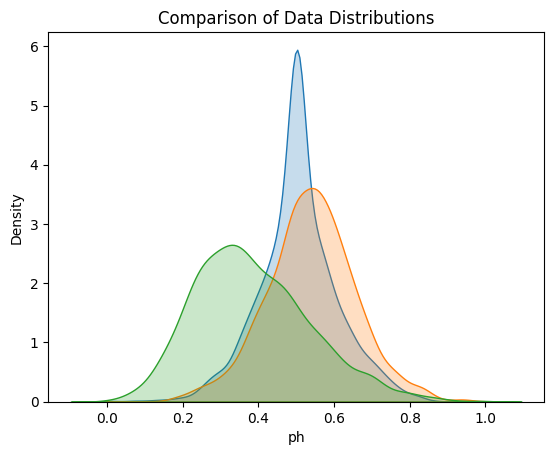

In [ ]:
# Creating a KDE plot
sns.kdeplot(X_train_norm,x="ph",fill=True)
sns.kdeplot(X_train_norm,x="Hardness",fill=True)
sns.kdeplot(X_train_norm,x="Solids",fill=True)
plt.title("Comparison of Data Distributions")
plt.show()

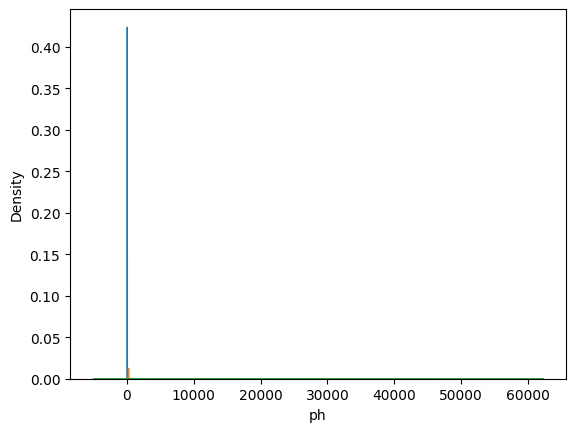

In [ ]:
# Create KDE PLot with Original Data
sns.kdeplot(X_train,x="ph",fill=True)
sns.kdeplot(X_train,x="Hardness",fill=True)
sns.kdeplot(X_train,x="Solids",fill=True)
plt.show()

### **Standard Scalar**

In [ ]:
# standard scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_stand=scaler.fit_transform(X_train)
X_test_stand=scaler.transform(X_test)

In [ ]:
X_train_stand=pd.DataFrame(X_train_stand,columns=X_train.columns)
X_train_stand.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.059279,-1.042731,0.400466,1.918550,-1.191302,0.345424,-0.985898,0.431903
1,0.686489,0.153387,0.501299,-0.255677,0.071380,-0.152843,-2.164976,0.531624
2,0.872981,-0.375791,-1.043708,-0.334030,0.832615,-0.398035,1.295776,-0.410433
3,0.413205,1.042647,-1.690613,0.538783,0.824974,-0.021327,0.470684,0.288762
4,-0.139838,0.734102,0.170242,-0.327320,-1.251290,-0.251306,1.447514,-0.186024


In [ ]:
X_test_stand=pd.DataFrame(X_test_stand,columns=X_train.columns)
X_test_stand.head()


,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.287445,1.235829,-0.040877,-0.341742,-1.580845,1.943630,0.104360,0.369003
1,0.787855,-1.220284,0.223074,0.317738,-0.101627,-0.313818,-0.006181,-0.538099
2,-0.064219,0.303815,0.067792,-0.756525,0.190335,-0.237621,0.719645,1.246078
3,-1.615699,-0.067442,2.917612,0.021109,1.242066,-0.123910,0.000805,0.615345
4,1.881671,0.843881,0.853526,0.366517,-0.872879,-0.030780,1.103786,0.998424


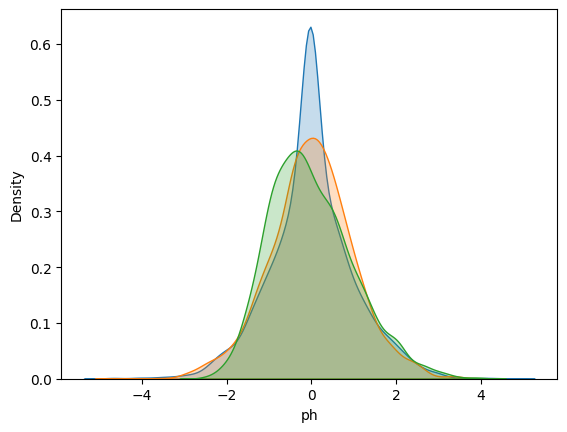

In [ ]:
sns.kdeplot(X_train_stand,x="ph",fill=True)
sns.kdeplot(X_train_stand,x="Hardness",fill=True)
sns.kdeplot(X_train_stand,x="Solids",fill=True)
plt.show()

### **Robust Scalar**

In [ ]:
# robust scaler
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train_robust=scaler.fit_transform(X_train)
X_test_robust=scaler.transform(X_test)

In [ ]:
X_train_robust=pd.DataFrame(X_train_robust,columns=X_train.columns)
X_train_robust.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.077323,-0.886366,0.386449,1.517967,-0.796104,0.272226,-0.774792,0.323765
1,0.667043,0.113036,0.461012,-0.209011,0.078010,-0.093243,-1.704554,0.397251
2,0.842387,-0.329113,-0.681479,-0.271247,0.604988,-0.273087,1.024423,-0.296972
3,0.410094,0.856044,-1.159847,0.422025,0.599698,0.003221,0.373796,0.218281
4,-0.109892,0.598244,0.216204,-0.265917,-0.837632,-0.165464,1.144076,-0.131600


In [ ]:
X_test_robust=pd.DataFrame(X_test_robust,columns=X_train.columns)
X_test_robust.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.291851,1.017456,0.060087,-0.277373,-1.065772,1.444480,0.084931,0.277413
1,0.762349,-1.034718,0.255272,0.246449,-0.041757,-0.211315,-0.002236,-0.391052
2,-0.038794,0.238723,0.140445,-0.606833,0.160358,-0.155427,0.570115,0.923750
3,-1.497536,-0.071476,2.247810,0.010838,0.888438,-0.072022,0.003274,0.458948
4,1.790784,0.689968,0.721474,0.285195,-0.575670,-0.003713,0.873029,0.741247


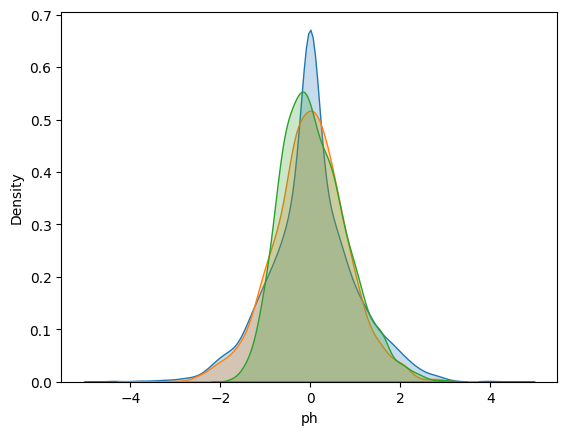

In [ ]:
sns.kdeplot(X_train_robust,x="ph",fill=True)
sns.kdeplot(X_train_robust,x="Hardness",fill=True)
sns.kdeplot(X_train_robust,x="Solids",fill=True)
plt.show()

# **Standard Scalar**

- if the features are normally distributed

- it is not much impacted by outliers

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_std=scalar.fit_transform(X_train)

In [ ]:
# Let us convert above data into a dataframe
X_train_std=pd.DataFrame(X_train_std,columns=X_train.columns)
X_train_std.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.059279,-1.042731,0.400466,1.918550,-1.191302,0.345424,-0.985898,0.431903
1,0.686489,0.153387,0.501299,-0.255677,0.071380,-0.152843,-2.164976,0.531624
2,0.872981,-0.375791,-1.043708,-0.334030,0.832615,-0.398035,1.295776,-0.410433
3,0.413205,1.042647,-1.690613,0.538783,0.824974,-0.021327,0.470684,0.288762
4,-0.139838,0.734102,0.170242,-0.327320,-1.251290,-0.251306,1.447514,-0.186024


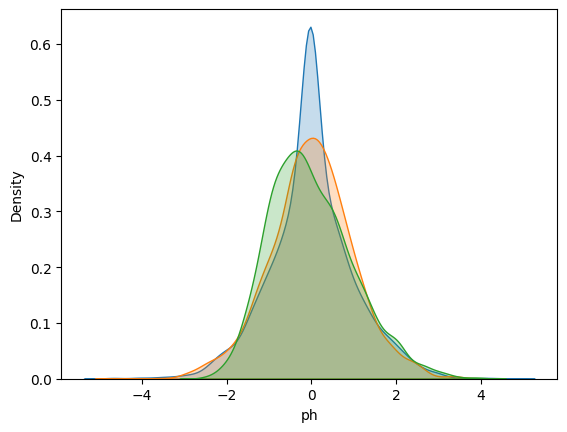

In [ ]:
sns.kdeplot(X_train_std, x="ph", fill=True)
sns.kdeplot(X_train_std, x="Hardness", fill=True)
sns.kdeplot(X_train_std, x="Solids", fill=True)
plt.show()

In [ ]:
# let us apply standard scalar on test data
X_test_std=scalar.transform(X_test)
# let us convert transformed data into data frame
X_test_std=pd.DataFrame(X_test_std,columns=X_test.columns)
X_test_std.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.287445,1.235829,-0.040877,-0.341742,-1.580845,1.943630,0.104360,0.369003
1,0.787855,-1.220284,0.223074,0.317738,-0.101627,-0.313818,-0.006181,-0.538099
2,-0.064219,0.303815,0.067792,-0.756525,0.190335,-0.237621,0.719645,1.246078
3,-1.615699,-0.067442,2.917612,0.021109,1.242066,-0.123910,0.000805,0.615345
4,1.881671,0.843881,0.853526,0.366517,-0.872879,-0.030780,1.103786,0.998424


### **Robust Scalar**

In [ ]:
from sklearn.preprocessing import RobustScaler
scalar=RobustScaler(quantile_range=(20.0, 80.0))
# Let us apply Robust Scalar to Train Data
X_train_rob=scalar.fit_transform(X_train)
# Let us convert above numpy array into a data frame
X_train_rob=pd.DataFrame(X_train_rob,columns=X_train.columns)
X_train_rob.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.057895,-0.677571,0.315589,1.202909,-0.650999,0.217912,-0.605739,0.259712
1,0.499443,0.086409,0.376480,-0.165630,0.063791,-0.074640,-1.332636,0.318661
2,0.630731,-0.251586,-0.556522,-0.214949,0.494717,-0.218602,0.800903,-0.238220
3,0.307055,0.654392,-0.947177,0.334432,0.490392,0.002578,0.292237,0.175097
4,-0.082281,0.457320,0.176561,-0.210725,-0.684957,-0.132451,0.894449,-0.105565


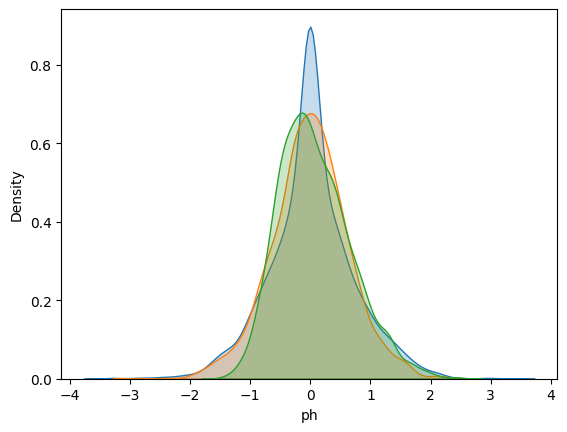

In [ ]:
sns.kdeplot(X_train_rob,x="ph",fill=True)
sns.kdeplot(X_train_rob,x="Hardness",fill=True)
sns.kdeplot(X_train_rob,x="Solids",fill=True)
plt.show()

In [ ]:
# Let us apply robust scalar to test data
X_test_rob=scalar.transform(X_test)
# Let us convert above numpy array into a Data Frame
X_test_rob=pd.DataFrame(X_test_rob,columns=X_test.columns)
X_test_rob.head()

,ph,Hardness,Solids,Chloramines,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.218521,0.777781,0.049070,-0.219803,-0.871515,1.156282,0.066400,0.222530
1,0.570804,-0.790976,0.208465,0.195298,-0.034146,-0.169154,-0.001748,-0.313688
2,-0.029046,0.182489,0.114693,-0.480883,0.131130,-0.124416,0.445721,0.740998
3,-1.121270,-0.054639,1.835649,0.008589,0.726503,-0.057652,0.002559,0.368151
4,1.340837,0.527437,0.589184,0.226002,-0.470743,-0.002972,0.682542,0.594601
